# ARIMA

## Importação de bibliotecas

In [46]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## Importação de dataset

In [2]:
data = pd.read_csv("../carne-brasileira-exportada.csv", encoding='utf-8', sep=',')
data.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
4,2014,1,suino,37.93,8.686,0.747,0.260,2.34,22.57,62.01,2.811


## Separação de dataset por carne

In [3]:
bovino = data[data['tipo_carne'] == 'bovino'].copy()
bovino.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
12,2015,1,bovino,215.20,7.737,1.836,0.993,2.87,22.95,60.01,4.279


In [ ]:
suino = data[data['tipo_carne'] == 'suino'].copy()
suino.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
12,2015,1,bovino,215.20,7.737,1.836,0.993,2.87,22.95,60.01,4.279


In [ ]:
frango = data[data['tipo_carne'] == 'frango'].copy()
frango.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
12,2015,1,bovino,215.20,7.737,1.836,0.993,2.87,22.95,60.01,4.279


### Ordenação temporal

In [6]:
bovino = bovino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [7]:
suino = suino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [8]:
frango = frango.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

## Adequação do dataset para o ARIMA

### Bovino

In [71]:
df = bovino.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

0     1.345
1     1.384
2     1.547
3     1.519
4     0.993
5     1.094
6     1.258
7     1.319
8     1.094
9     1.117
10    1.065
11    1.059
12    1.079
13    1.094
14    1.436
15    1.460
16    1.300
17    0.888
18    1.735
19    1.534
20    1.257
21    1.336
22    1.678
23    2.258
24    1.623
25    1.846
26    1.928
27    2.071
28    1.564
29    1.950
30    3.014
31    1.437
32    2.616
33    3.003
34    3.558
35    2.636
36    1.988
37    2.358
38    2.482
39    2.666
40    2.383
41    2.756
42    3.146
43    3.374
Name: exportacao_usd, dtype: float64

#### Visualização da série

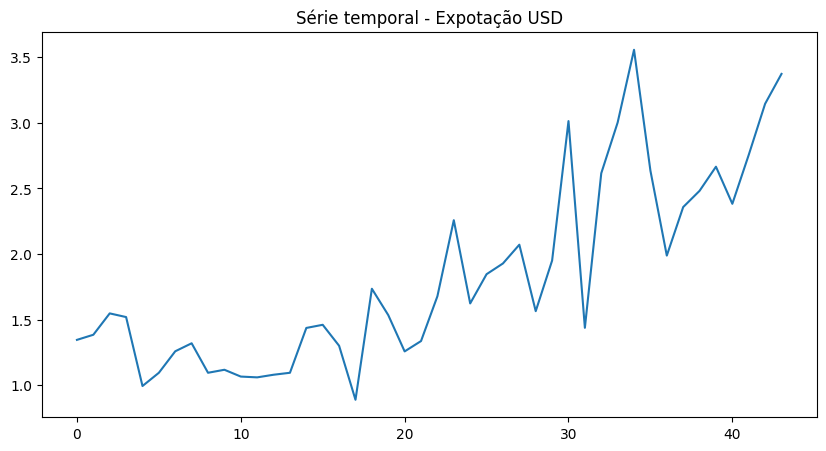

In [19]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [23]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.3984508790039688
p-value: 0.9814369176419221


**Interpretação**:

* p < 0.05 → estacionária
* p > 0.05 → precisa diferenciar (d > 0)

#### Tornar estacionário

In [27]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -3.665044253301742
p-value: 0.004632585570749461


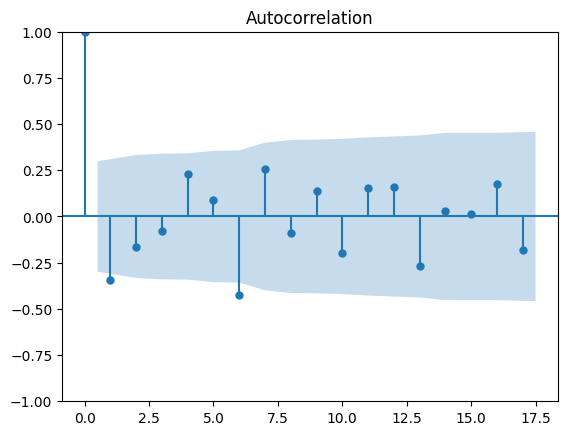

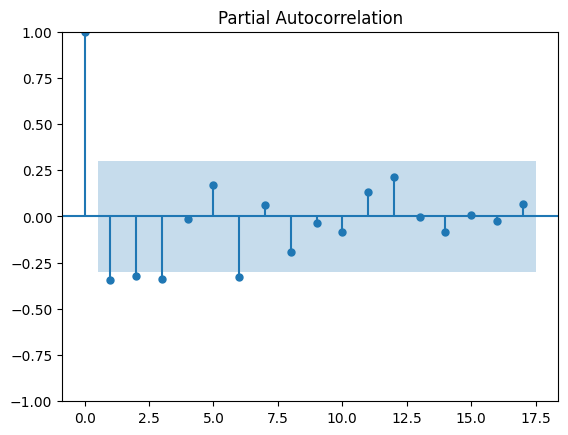

In [31]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

**Interpretação**:

* X-axis → lag
* Y-axis → força de correlação
* Pontos fora da área de confiança → correlação significativa

#### Treinamento do modelo ARIMA

In [66]:
model = ARIMA(series, order=(2, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 -25.548
Date:                Wed, 08 Apr 2026   AIC                             57.095
Time:                        15:04:31   BIC                             62.379
Sample:                             0   HQIC                            59.044
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4358      0.093     -4.665      0.000      -0.619      -0.253
ar.L2         -0.3033      0.103     -2.958      0.003      -0.504      -0.102
sigma2         0.1907      0.036      5.268      0.0

In [75]:
model = ARIMA(series, order=(3, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   44
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -23.057
Date:                Wed, 08 Apr 2026   AIC                             56.114
Time:                        15:43:37   BIC                             64.920
Sample:                             0   HQIC                            59.362
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5589      0.402     -1.390      0.164      -1.347       0.229
ar.L2         -0.4700      0.271     -1.737      0.082      -1.000       0.060
ar.L3         -0.3345      0.236     -1.418      0.1

#### Realizando previsões

In [76]:
forecast = model_fit.forecast(steps=5)

print(forecast)

44    2.942998
45    2.946287
46    3.070754
47    3.143809
48    3.043376
Name: predicted_mean, dtype: float64


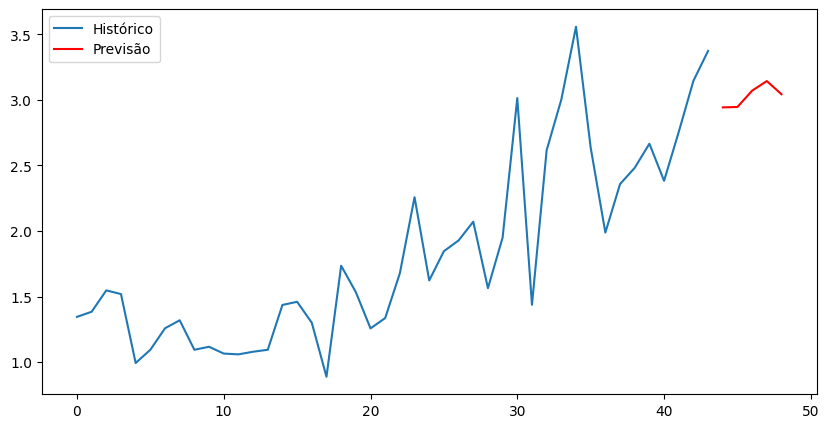

In [77]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [78]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, predictions)
print("MSE:", mse)

MSE: 0.4898374265249868
